# Project 1: LendingClub Interest Rate Prediction — Neural Network Model

<small>OPAN 6604 AI Modeling in Practice. Target: `int_rate`. Model focus: leakage-controlled neural network regression with staged sampling for efficient development.</small>

**Main idea:** build a reproducible preprocessing + neural network workflow, evaluate it with RMSE as the north-star metric, and generate a properly formatted prediction CSV for `LC_test.csv`.

## Step 0: Setup

This section imports the packages, fixes the random seed, and defines file paths. The code uses scikit-learn's `MLPRegressor`, which is a feed-forward neural network for regression.

In [1]:
import os
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    root_mean_squared_error = None
from scipy.stats import loguniform

warnings.filterwarnings("ignore")
RANDOM_STATE = 6604

TRAIN_PATH = "LC_train.csv"
TEST_PATH = "LC_test.csv"
OUTPUT_CSV = "NEURAL_NETWORK_SUBMISSION.csv"  # Rename later to SectionNameGroupNumber.csv, e.g., HOYA1.csv

## Step 1: Compute strategy — staged sampling

The full training file has about 100,000 loans. To avoid crashing my laptop, I used staged sampling:

- **Debug sample:** confirms preprocessing and model code runs.
- **Compare sample:** produces quick initial results.
- **Tune sample:** tunes a small set of neural network hyperparameters.
- **Final sample:** fits the selected workflow on the largest feasible sample.

Increase these values only if runtime and memory are acceptable.

In [2]:
# Set these to smaller/larger values depending on laptop performance.
DEBUG_SAMPLE_SIZE = 10_000
COMPARE_SAMPLE_SIZE = 30_000
TUNE_SAMPLE_SIZE = 40_000
FINAL_SAMPLE_SIZE = 60_000   # Set to None to use all 100k rows if feasible.

VALIDATION_SIZE = 0.20
CV_FOLDS = 3
N_ITER_SEARCH = 10           # Increase to 20+ if time allows.
MAX_ITER_NN = 250            # Increase if the model has not converged and runtime is acceptable.

## Step 2: Load the data

`LC_train.csv` includes the target variable `int_rate`. `LC_test.csv` removes `int_rate` and adds `ID` for the prediction submission.

In [3]:
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print("Target present in train:", "int_rate" in train_raw.columns)
print("ID present in test:", "ID" in test_raw.columns)

train_raw.head()

Train shape: (100000, 39)
Test shape: (10000, 39)
Target present in train: True
ID present in test: True


,addr_state,all_util,annual_inc,application_type,chargeoff_within_12_mths,collections_12_mths_ex_med,delinq_2yrs,dti,emp_length,emp_title,...,revol_util,term,title,tot_coll_amt,tot_cur_bal,total_acc,total_bal_ex_mort,verification_status,zip_code,int_rate
0,TX,80.0,36000.0,Individual,0,0,0,26.33,NaN,NaN,...,70.9,36 months,Other,0,34683.0,7,34683,Verified,780xx,18.62
1,RI,61.0,45000.0,Individual,0,0,0,38.51,1 year,Composite Boat Builder,...,42.6,60 months,Debt consolidation,0,63873.0,18,63873,Not Verified,028xx,16.08
2,CA,31.0,53040.0,Individual,0,0,0,25.20,< 1 year,Fed-Ex Ground Driver,...,12.6,36 months,Credit card refinancing,0,333107.0,26,24452,Verified,920xx,7.56
3,NY,87.0,125000.0,Individual,0,0,0,27.87,10+ years,Financial Service Leader,...,93.2,36 months,Debt consolidation,0,342153.0,38,141033,Verified,124xx,17.30
4,PA,75.0,73000.0,Individual,0,0,0,35.12,10+ years,Environmental Scientist,...,25.3,36 months,Debt consolidation,0,426837.0,36,160302,Not Verified,194xx,10.81


## Step 3: Quick EDA checks

This gives enough EDA for model setup: target distribution, missing values, and variable types. Save deeper charts for the group slide deck if needed.

count    100000.000000
mean         12.946763
std           5.255559
min           6.460000
25%           8.190000
50%          11.710000
75%          16.120000
max          30.990000
Name: int_rate, dtype: float64


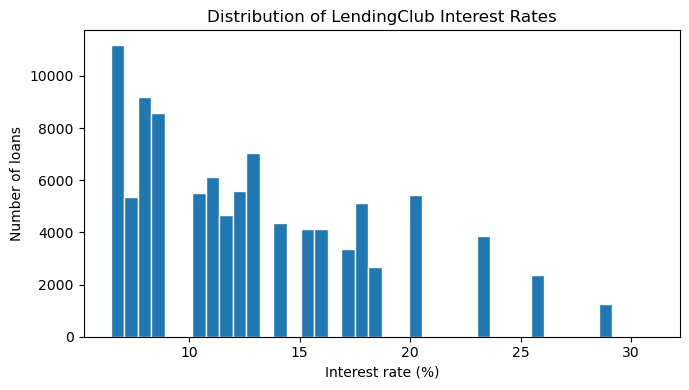

,missing_rate
mths_since_last_record,0.90875
emp_title,0.14920
mths_since_recent_inq,0.09975
emp_length,0.08669
mths_since_rcnt_il,0.02204
mo_sin_old_il_acct,0.02204
mths_since_recent_bc,0.00920
dti,0.00186
revol_util,0.00123
all_util,0.00016


In [4]:
TARGET = "int_rate"

print(train_raw[TARGET].describe())

plt.figure(figsize=(7, 4))
plt.hist(train_raw[TARGET], bins=40, edgecolor="white")
plt.xlabel("Interest rate (%)")
plt.ylabel("Number of loans")
plt.title("Distribution of LendingClub Interest Rates")
plt.tight_layout()
plt.show()

missing_summary = (
    train_raw.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)
missing_summary.head(15)

## Step 4: Leakage and feature assumptions

The most important modeling assumption is that the model should use information available at or before loan origination. 

**Removed as leakage or non-predictive identifiers:**
- `loan_status`: loan outcome/status after origination; unsafe for pricing prediction.
- `ID`: test identifier only, not a borrower risk feature.

**Removed for neural-network efficiency / high cardinality:**
- `emp_title`, `title`, `zip_code`: very sparse text-like or high-cardinality features. These may be explored by another teammate, but they can make a neural network slower and harder to generalize.

**Transformed:**
- `term` → numeric months.
- `emp_length` → numeric years.
- FICO low/high → average FICO score.
- Several borrower-balance ratios are added.

In [5]:
LEAKAGE_DROP_COLS = ["loan_status"]
HIGH_CARD_DROP_COLS = ["emp_title", "title", "zip_code"]
ID_COL = "ID"

# Safe divide helper avoids infinite values when income is missing or zero.
def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def parse_emp_length(value):
    """Convert employment length strings to numeric years."""
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    if value in ["< 1 year", "less than 1 year"]:
        return 0
    if "10+" in value:
        return 10
    match = re.search(r"\d+", value)
    return float(match.group()) if match else np.nan


def preprocess_features(df, is_train=True):
    """Apply lightweight feature engineering before the sklearn pipeline."""
    df = df.copy()

    # Drop columns that should not be used as predictors.
    drop_cols = []
    if is_train and TARGET in df.columns:
        drop_cols.append(TARGET)
    if ID_COL in df.columns:
        drop_cols.append(ID_COL)
    drop_cols += [c for c in LEAKAGE_DROP_COLS + HIGH_CARD_DROP_COLS if c in df.columns]
    X = df.drop(columns=drop_cols, errors="ignore")

    # Convert loan term from strings such as "36 months" to numeric months.
    if "term" in X.columns:
        X["term_months"] = X["term"].astype(str).str.extract(r"(\d+)").astype(float)
        X = X.drop(columns=["term"])

    # Convert employment length to numeric years.
    if "emp_length" in X.columns:
        X["emp_length_num"] = X["emp_length"].apply(parse_emp_length)
        X = X.drop(columns=["emp_length"])

    # Combine FICO low/high boundaries into one average score.
    if {"fico_range_low", "fico_range_high"}.issubset(X.columns):
        X["fico_avg"] = X[["fico_range_low", "fico_range_high"]].mean(axis=1)
        X = X.drop(columns=["fico_range_low", "fico_range_high"])

    # Simple ratios that connect requested loan/balances to borrower income.
    if {"loan_amnt", "annual_inc"}.issubset(X.columns):
        X["loan_to_income"] = safe_divide(X["loan_amnt"], X["annual_inc"])
    if {"revol_bal", "annual_inc"}.issubset(X.columns):
        X["revol_bal_to_income"] = safe_divide(X["revol_bal"], X["annual_inc"])
    if {"total_bal_ex_mort", "annual_inc"}.issubset(X.columns):
        X["total_bal_ex_mort_to_income"] = safe_divide(X["total_bal_ex_mort"], X["annual_inc"])
    if {"tot_cur_bal", "annual_inc"}.issubset(X.columns):
        X["tot_cur_bal_to_income"] = safe_divide(X["tot_cur_bal"], X["annual_inc"])

    # Replace infinities created by unusual data values.
    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X_all = preprocess_features(train_raw, is_train=True)
y_all = train_raw[TARGET].copy()
X_test_final = preprocess_features(test_raw, is_train=False)

print("Features after engineering:", X_all.shape[1])
print("Columns used by neural network:")
print(X_all.columns.tolist())

Features after engineering: 37
Columns used by neural network:
['addr_state', 'all_util', 'annual_inc', 'application_type', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'home_ownership', 'inq_fi', 'inq_last_12m', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mort_acc', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_inq', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'tot_coll_amt', 'tot_cur_bal', 'total_acc', 'total_bal_ex_mort', 'verification_status', 'term_months', 'emp_length_num', 'fico_avg', 'loan_to_income', 'revol_bal_to_income', 'total_bal_ex_mort_to_income', 'tot_cur_bal_to_income']


## Step 5: Build preprocessing pipeline

The neural network needs scaled numeric features. Categorical variables are imputed and one-hot encoded. Numeric variables are median-imputed, missingness indicators are added, and values are standardized.

In [6]:
numeric_features = X_all.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_all.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)
print("\nCategorical features:", len(categorical_features))
print(categorical_features)

# Compatibility helper because OneHotEncoder changed 'sparse' to 'sparse_output' in newer sklearn versions.
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_ohe())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

Numeric features: 32
['all_util', 'annual_inc', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'inq_fi', 'inq_last_12m', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mort_acc', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_inq', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'revol_bal', 'revol_util', 'tot_coll_amt', 'tot_cur_bal', 'total_acc', 'total_bal_ex_mort', 'term_months', 'emp_length_num', 'fico_avg', 'loan_to_income', 'revol_bal_to_income', 'total_bal_ex_mort_to_income', 'tot_cur_bal_to_income']

Categorical features: 5
['addr_state', 'application_type', 'home_ownership', 'purpose', 'verification_status']


## Step 6: Helper functions for sampling and evaluation

RMSE is the north-star metric because the project competition is based on RMSE. MAE and R² are supporting metrics. The train-validation gap helps detect overfitting.

In [7]:
def sample_training_data(X, y, sample_size, random_state=RANDOM_STATE):
    """Return a random sample for faster modeling. If sample_size is None, return all rows."""
    if sample_size is None or sample_size >= len(X):
        return X.copy(), y.copy()
    sampled_idx = X.sample(n=sample_size, random_state=random_state).index
    return X.loc[sampled_idx].copy(), y.loc[sampled_idx].copy()


def rmse(y_true, y_pred):
    """Return RMSE. Compatible with older and newer scikit-learn versions."""
    if root_mean_squared_error is not None:
        return root_mean_squared_error(y_true, y_pred)
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_model(name, model, X_train, y_train, X_valid, y_valid):
    """Fit model and return train/validation metrics."""
    start = time.time()
    model.fit(X_train, y_train)
    runtime = time.time() - start

    train_pred = model.predict(X_train)
    valid_pred = model.predict(X_valid)

    result = {
        "model": name,
        "train_RMSE": rmse(y_train, train_pred),
        "valid_RMSE": rmse(y_valid, valid_pred),
        "train_MAE": mean_absolute_error(y_train, train_pred),
        "valid_MAE": mean_absolute_error(y_valid, valid_pred),
        "train_R2": r2_score(y_train, train_pred),
        "valid_R2": r2_score(y_valid, valid_pred),
        "RMSE_gap": rmse(y_valid, valid_pred) - rmse(y_train, train_pred),
        "runtime_seconds": runtime,
    }
    return result

## Step 7: Pipeline debug on a small sample

This confirms that preprocessing, encoding, scaling, and neural-network fitting run successfully before we spend time tuning.

In [8]:
X_debug, y_debug = sample_training_data(X_all, y_all, DEBUG_SAMPLE_SIZE)
X_train_dbg, X_valid_dbg, y_train_dbg, y_valid_dbg = train_test_split(
    X_debug, y_debug,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE
)

small_nn = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.15,
        max_iter=150,
        random_state=RANDOM_STATE
    ))
])

debug_result = evaluate_model("Debug Neural Network", small_nn, X_train_dbg, y_train_dbg, X_valid_dbg, y_valid_dbg)
pd.DataFrame([debug_result]).round(4)

,model,train_RMSE,valid_RMSE,train_MAE,valid_MAE,train_R2,valid_R2,RMSE_gap,runtime_seconds
0,Debug Neural Network,3.9113,4.2382,2.9843,3.2397,0.4568,0.3559,0.3269,1.1253


## Step 8: Initial model comparison

Even though your assigned model is neural networks, we include a dummy baseline and a regularized linear model so the neural network result has context. Other teammates may contribute tree-based models.

In [9]:
X_compare, y_compare = sample_training_data(X_all, y_all, COMPARE_SAMPLE_SIZE)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_compare, y_compare,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE
)

models = {
    "Dummy Mean Baseline": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]),
    "Ridge Baseline": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", Ridge(alpha=10.0, random_state=RANDOM_STATE))
    ]),
    "Neural Network Baseline": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.001,
            learning_rate_init=0.001,
            early_stopping=True,
            validation_fraction=0.15,
            max_iter=MAX_ITER_NN,
            random_state=RANDOM_STATE
        ))
    ])
}

comparison_results = []
for name, model in models.items():
    print(f"Fitting {name}...")
    comparison_results.append(evaluate_model(name, model, X_train, y_train, X_valid, y_valid))

comparison_table = pd.DataFrame(comparison_results).sort_values("valid_RMSE")
comparison_table.round(4)

Fitting Dummy Mean Baseline...
Fitting Ridge Baseline...
Fitting Neural Network Baseline...


,model,train_RMSE,valid_RMSE,train_MAE,valid_MAE,train_R2,valid_R2,RMSE_gap,runtime_seconds
2,Neural Network Baseline,3.8775,4.0395,2.9294,3.0178,0.4610,0.3974,0.1620,2.7492
1,Ridge Baseline,4.2818,4.2575,3.3238,3.2649,0.3428,0.3306,-0.0243,0.0682
0,Dummy Mean Baseline,5.2816,5.2068,4.2900,4.2568,0.0000,-0.0012,-0.0748,0.0762


In [17]:
# ============================================================
# Optional: OOF evaluation for Baseline Neural Network
# ============================================================

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import time

# Use the same sample size as initial comparison, or increase if runtime is okay
X_oof, y_oof = sample_training_data(X_all, y_all, COMPARE_SAMPLE_SIZE)

baseline_nn_oof = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.01,
        learning_rate_init=0.0005,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        max_iter=1000,
        batch_size=256,
        random_state=RANDOM_STATE
    ))
])

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_predictions = np.zeros(len(X_oof))
fold_results = []

start = time.time()

for fold, (train_idx, valid_idx) in enumerate(kf.split(X_oof), start=1):
    print(f"Training fold {fold}/{N_SPLITS}...")

    X_train_fold = X_oof.iloc[train_idx]
    X_valid_fold = X_oof.iloc[valid_idx]
    y_train_fold = y_oof.iloc[train_idx]
    y_valid_fold = y_oof.iloc[valid_idx]

    model_fold = clone(baseline_nn_oof)
    model_fold.fit(X_train_fold, y_train_fold)

    valid_pred = model_fold.predict(X_valid_fold)
    oof_predictions[valid_idx] = valid_pred

    fold_rmse = rmse(y_valid_fold, valid_pred)
    fold_mae = mean_absolute_error(y_valid_fold, valid_pred)
    fold_r2 = r2_score(y_valid_fold, valid_pred)

    fold_results.append({
        "fold": fold,
        "RMSE": fold_rmse,
        "MAE": fold_mae,
        "R2": fold_r2
    })

fold_table = pd.DataFrame(fold_results)

oof_rmse = rmse(y_oof, oof_predictions)
oof_mae = mean_absolute_error(y_oof, oof_predictions)
oof_r2 = r2_score(y_oof, oof_predictions)

print("\nOOF runtime minutes:", round((time.time() - start) / 60, 2))
print("Baseline Neural Network OOF RMSE:", round(oof_rmse, 4))
print("Baseline Neural Network OOF MAE:", round(oof_mae, 4))
print("Baseline Neural Network OOF R²:", round(oof_r2, 4))

fold_table.round(4)

Training fold 1/5...
Training fold 2/5...
Training fold 3/5...
Training fold 4/5...
Training fold 5/5...

OOF runtime minutes: 0.4
Baseline Neural Network OOF RMSE: 5.1007
Baseline Neural Network OOF MAE: 3.1138
Baseline Neural Network OOF R²: 0.062


,fold,RMSE,MAE,R2
0,1,4.0621,3.0345,0.3906
1,2,4.1145,3.1508,0.3892
2,3,7.9626,3.2037,-1.2220
3,4,4.1327,3.1550,0.3834
4,5,4.0219,3.0249,0.4144


## Step 9: Tune the neural network with RandomizedSearchCV

This searches a small hyperparameter space. The search is intentionally modest because neural networks can be slow on 100k rows. Increase `N_ITER_SEARCH` only if runtime is acceptable.

In [10]:
X_tune, y_tune = sample_training_data(X_all, y_all, TUNE_SAMPLE_SIZE)
X_train_tune, X_valid_tune, y_train_tune, y_valid_tune = train_test_split(
    X_tune, y_tune,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE
)

nn_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPRegressor(
        activation="relu",
        solver="adam",
        early_stopping=True,
        validation_fraction=0.15,
        max_iter=MAX_ITER_NN,
        random_state=RANDOM_STATE
    ))
])

param_distributions = {
    "model__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64), (128, 64, 32)],
    "model__alpha": loguniform(1e-5, 1e-2),
    "model__learning_rate_init": loguniform(1e-4, 5e-3),
    "model__batch_size": [128, 256, 512],
}

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=nn_pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER_SEARCH,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    return_train_score=True
)

start = time.time()
random_search.fit(X_train_tune, y_train_tune)
print("Tuning runtime minutes:", round((time.time() - start) / 60, 2))
print("Best CV RMSE:", round(-random_search.best_score_, 4))
print("Best parameters:")
print(random_search.best_params_)

# Evaluate tuned model on the held-out validation set from the tuning sample.
tuned_nn = random_search.best_estimator_
tuned_train_pred = tuned_nn.predict(X_train_tune)
tuned_valid_pred = tuned_nn.predict(X_valid_tune)

tuned_result = {
    "model": "Tuned Neural Network",
    "train_RMSE": rmse(y_train_tune, tuned_train_pred),
    "valid_RMSE": rmse(y_valid_tune, tuned_valid_pred),
    "train_MAE": mean_absolute_error(y_train_tune, tuned_train_pred),
    "valid_MAE": mean_absolute_error(y_valid_tune, tuned_valid_pred),
    "train_R2": r2_score(y_train_tune, tuned_train_pred),
    "valid_R2": r2_score(y_valid_tune, tuned_valid_pred),
    "RMSE_gap": rmse(y_valid_tune, tuned_valid_pred) - rmse(y_train_tune, tuned_train_pred),
}

pd.DataFrame([tuned_result]).round(4)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Tuning runtime minutes: 0.31
Best CV RMSE: 4.3286
Best parameters:
{'model__alpha': np.float64(4.731912328944503e-05), 'model__batch_size': 512, 'model__hidden_layer_sizes': (32,), 'model__learning_rate_init': np.float64(0.0030276803997712973)}


,model,train_RMSE,valid_RMSE,train_MAE,valid_MAE,train_R2,valid_R2,RMSE_gap
0,Tuned Neural Network,3.9768,4.1784,2.9966,3.1466,0.4285,0.3793,0.2016


## Step 10: Explainability technique 1 — permutation importance

Permutation importance measures how much validation RMSE worsens when each feature is randomly shuffled. Larger increases mean the model depends more on that feature.

For speed, this uses a validation subsample.

In [11]:
# Use a small validation sample for explainability speed.
EXPLAIN_SAMPLE_SIZE = min(3_000, len(X_valid_tune))
X_explain = X_valid_tune.sample(n=EXPLAIN_SAMPLE_SIZE, random_state=RANDOM_STATE)
y_explain = y_valid_tune.loc[X_explain.index]

perm = permutation_importance(
    tuned_nn,
    X_explain,
    y_explain,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X_explain.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_importance.head(15)

,feature,importance_mean,importance_std
32,fico_avg,0.907694,0.038222
30,term_months,0.380116,0.008437
7,dti,0.335350,0.016235
22,purpose,0.216460,0.011166
16,mths_since_rcnt_il,0.120921,0.012735
33,loan_to_income,0.112621,0.007532
24,revol_util,0.087349,0.019135
11,loan_amnt,0.086444,0.011134
1,all_util,0.084056,0.003801
34,revol_bal_to_income,0.058018,0.011310


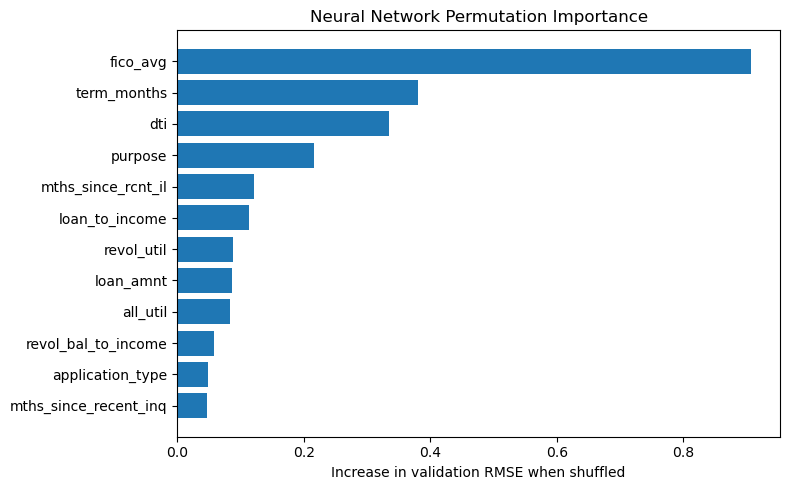

In [12]:
top_perm = perm_importance.head(12).sort_values("importance_mean")

plt.figure(figsize=(8, 5))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.xlabel("Increase in validation RMSE when shuffled")
plt.title("Neural Network Permutation Importance")
plt.tight_layout()
plt.show()

## Step 11: Explainability technique 2 — partial dependence style plots

This creates simple one-feature sensitivity plots for important numeric variables. It changes one variable across a grid while holding other validation rows fixed, then averages the predicted interest rate.

This is not a full causal claim; it shows the model's learned relationship.

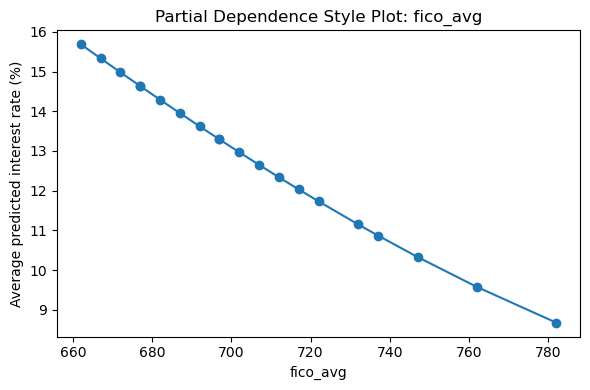

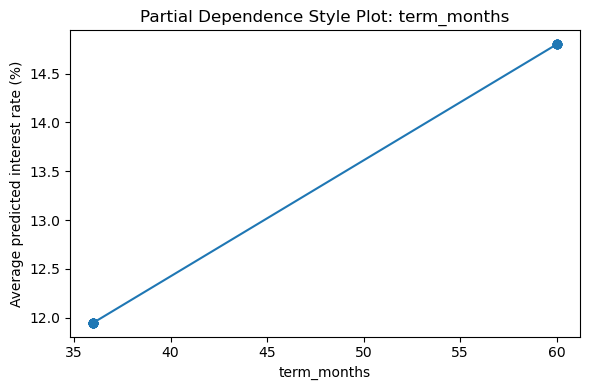

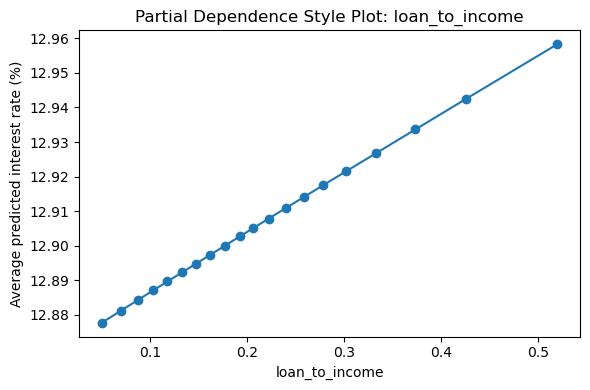

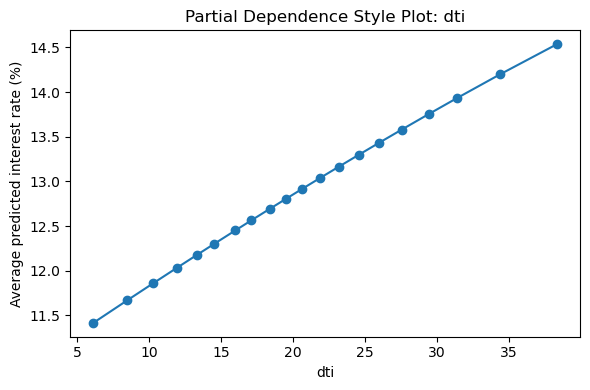

In [13]:
def partial_dependence_manual(model, X_reference, feature, grid_points=20):
    """Manual partial dependence for one numeric feature."""
    grid = np.nanpercentile(X_reference[feature], np.linspace(5, 95, grid_points))
    preds = []
    X_temp = X_reference.copy()
    for value in grid:
        X_temp[feature] = value
        preds.append(model.predict(X_temp).mean())
    return pd.DataFrame({feature: grid, "predicted_int_rate": preds})

candidate_features = [
    "fico_avg", "term_months", "loan_to_income", "dti", "revol_util", "annual_inc", "loan_amnt"
]
features_for_pd = [f for f in candidate_features if f in X_explain.columns]

for feature in features_for_pd[:4]:
    pd_curve = partial_dependence_manual(tuned_nn, X_explain.copy(), feature)
    plt.figure(figsize=(6, 4))
    plt.plot(pd_curve[feature], pd_curve["predicted_int_rate"], marker="o")
    plt.xlabel(feature)
    plt.ylabel("Average predicted interest rate (%)")
    plt.title(f"Partial Dependence Style Plot: {feature}")
    plt.tight_layout()
    plt.show()

## Step 12: Final-fit neural network on the largest feasible sample

This refits the tuned neural network structure on the final training sample. Start with `FINAL_SAMPLE_SIZE = 60_000`. If runtime is acceptable, set it to `None` to use all 100k rows.

In [14]:
X_final_fit, y_final_fit = sample_training_data(X_all, y_all, FINAL_SAMPLE_SIZE)
print("Final fit rows:", len(X_final_fit))

# Reuse best parameters found by RandomizedSearchCV.
final_nn = random_search.best_estimator_

start = time.time()
final_nn.fit(X_final_fit, y_final_fit)
print("Final fit runtime minutes:", round((time.time() - start) / 60, 2))

Final fit rows: 60000
Final fit runtime minutes: 0.04


## Step 13: Generate prediction CSV

The required prediction file has exactly two columns: `ID` and `int_rate`. The predictions are clipped to 0–100 to satisfy submission requirements.

In [15]:
test_predictions = final_nn.predict(X_test_final)
test_predictions = np.clip(test_predictions, 0, 100)

submission = pd.DataFrame({
    "ID": test_raw[ID_COL],
    "int_rate": test_predictions
})

# Format sanity checks.
assert list(submission.columns) == ["ID", "int_rate"]
assert len(submission) == len(test_raw)
assert submission["int_rate"].between(0, 100).all()
assert pd.api.types.is_numeric_dtype(submission["int_rate"])

submission.to_csv(OUTPUT_CSV, index=False)
print("Saved:", OUTPUT_CSV)
submission.head()

Saved: NEURAL_NETWORK_SUBMISSION.csv


,ID,int_rate
0,1,12.964429
1,2,13.948170
2,3,7.641922
3,4,15.680337
4,5,15.001473


## Step 14: Main Interpretation

Built a leakage-controlled neural-network regression workflow for predicting int_rate. Removed loan_status because it reflects post-origination information, and I dropped very high-cardinality text-like fields. The model was evaluated using RMSE, MAE, R², and train-validation gap.

Main interpretation:
The neural-network regression workflow was useful as an alternative model experiment, but it was not selected as a final candidate. One validation fold became unstable, making the aggregate NN metrics unreliable. This suggests the NN configuration was sensitive to fold composition, preprocessing/scaling, or training parameters. Compared with the boosted-tree and stacked ensemble models, the NN approach was less stable and less suitable for final submission under the project timeline.